<a href="https://colab.research.google.com/github/VidhuRana/astralai/blob/main/AstralAI_Week1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AstralAI — Week One: Prove the ML Works

**The only goal this week:** train a galaxy classifier and produce one Grad-CAM heatmap. No auth, no dashboard, no UI. If this notebook runs top to bottom and you get a real accuracy number plus a heatmap that lands on the galaxy, the whole project is viable and we build the platform next week.

**How to use this notebook:** read the text cell, then run the code cell under it. Every code cell is explained in plain language first. You already know how to program — what's new here is the *domain* (PyTorch, transfer learning, Grad-CAM), so the comments focus on that.

**Before you start:** go to `Runtime -> Change runtime type -> Hardware accelerator -> GPU (T4)`. Everything below assumes a GPU.


## Step 0 — Confirm you have a GPU

Training on CPU would take hours; on a T4 GPU it's minutes. This cell must print `GPU available: True`. If it prints `False`, you didn't switch the runtime to GPU — do that first (see the note above), then re-run.

In [2]:
import torch
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU name: Tesla T4


## Step 1 — Get the dataset (once) onto Google Drive

**Galaxy10 DECaLS** is ~17,700 telescope images (256x256, colour) sorted into 10 morphology classes. It ships as a single `.h5` file, about **2.7 GB**.

The trap with Colab: your session disk is wiped when the runtime restarts, so if you download to the session you'll re-download 2.7 GB every time. Instead we mount your Google Drive and download there **once** — every future session just reads it back instantly.

Running this cell will pop up a Google sign-in to authorise Drive access. That's expected.

> **If the download URL below fails** (these hosts occasionally move), use the official loader instead — in a fresh cell run `!pip install astroNN -q` then `from astroNN.datasets import load_galaxy10; images, labels = load_galaxy10()` and skip to Step 3. It downloads the same data. (It also pulls in TensorFlow as a side effect, which we simply won't use.)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR = '/content/drive/MyDrive/astralai'
os.makedirs(DATA_DIR, exist_ok=True)
H5_PATH = os.path.join(DATA_DIR, 'Galaxy10_DECals.h5')

if not os.path.exists(H5_PATH):
    print("Downloading Galaxy10 DECaLS (~2.7 GB). One time only...")
    !wget -q --show-progress -O "$H5_PATH" https://www.astro.utoronto.ca/~hleung/shared/Galaxy10/Galaxy10_DECals.h5
    print("Done.")
else:
    print("Already on Drive:", H5_PATH)

Mounted at /content/drive
Already on Drive: /content/drive/MyDrive/astralai/Galaxy10_DECals.h5


## Step 2 — Load the file and see what's inside

An `.h5` file is like a labelled container of arrays. We pull out two things:
- `images` — shape `(N, 256, 256, 3)`, raw pixel values 0-255 (`uint8`)
- `ans` — shape `(N,)`, the correct class for each image as a number 0-9

Printing the shapes is your first sanity check: `N` should be ~17,736 for both, and they must match.

In [4]:
import h5py
import numpy as np

with h5py.File(H5_PATH, 'r') as f:
    print("Keys in file:", list(f.keys()))
    images = np.array(f['images'])   # (N, 256, 256, 3) uint8
    labels = np.array(f['ans'])      # (N,) class index 0-9

print("Images:", images.shape, images.dtype)
print("Labels:", labels.shape, labels.dtype)

Keys in file: ['ans', 'dec', 'images', 'pxscale', 'ra', 'redshift']
Images: (17736, 256, 256, 3) uint8
Labels: (17736,) uint8


## Step 3 — Meet the 10 classes, and check the balance

These are the ten morphology types, in order. The class index in `labels` maps to this list.

We also count how many images fall in each class. Astronomy datasets are almost always **imbalanced** — some galaxy types are far rarer than others. You're not fixing that this week; you just need to *know* it, because it explains why a model might ace common classes and stumble on rare ones.

In [5]:
CLASS_NAMES = [
    "Disturbed", "Merging", "Round Smooth", "In-between Round Smooth",
    "Cigar Shaped Smooth", "Barred Spiral", "Unbarred Tight Spiral",
    "Unbarred Loose Spiral", "Edge-on without Bulge", "Edge-on with Bulge",
]

import collections
counts = collections.Counter(labels.tolist())
for i, name in enumerate(CLASS_NAMES):
    print(f"{i}: {name:26s} {counts.get(i, 0):5d} images")

0: Disturbed                   1081 images
1: Merging                     1853 images
2: Round Smooth                2645 images
3: In-between Round Smooth     2027 images
4: Cigar Shaped Smooth          334 images
5: Barred Spiral               2043 images
6: Unbarred Tight Spiral       1829 images
7: Unbarred Loose Spiral       2628 images
8: Edge-on without Bulge       1423 images
9: Edge-on with Bulge          1873 images


## Step 4 — Actually *look* at the galaxies

The step most people skip — and it's the one that catches silent problems. Before trusting any model, look at a grid of real images with their labels. You want to build intuition for what "spiral" vs "elliptical" vs "edge-on" actually look like, and confirm the images and labels line up sensibly. Run this a few times to see different samples.

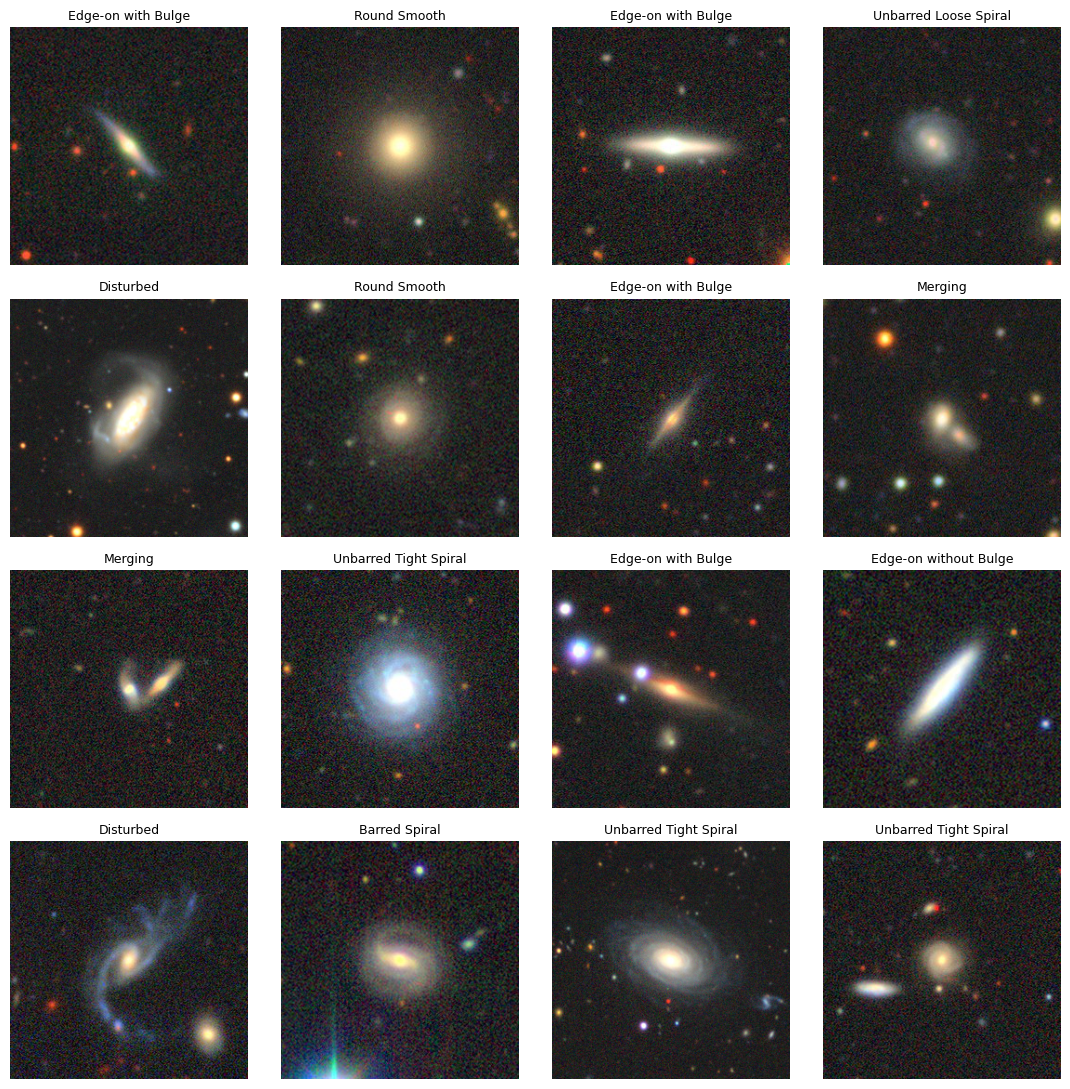

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(11, 11))
for ax in axes.flat:
    idx = np.random.randint(len(images))
    ax.imshow(images[idx])
    ax.set_title(CLASS_NAMES[int(labels[idx])], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Step 5 — Split the data and build the input pipeline

Three ideas new to you here, all standard:

**Train/validation split.** We train on 80% and hold back 20% the model never sees during training. Accuracy on that held-back set is the honest measure — accuracy on data it trained on is meaningless. We use a *stratified* split so each class keeps the same proportion in both halves.

**Normalization.** The pretrained model we'll use (next step) was trained on images scaled a specific way (the "ImageNet" mean/std). We must feed it images scaled the same way, or it sees garbage. This is a fixed, copy-paste convention.

**Augmentation (training set only).** We randomly flip and rotate training images. Galaxies have no natural "up," so a rotated spiral is still a valid spiral — this hands the model free extra variety and reduces overfitting. We do **not** augment the validation set; that must stay a clean, fixed yardstick.

`DataLoader` is PyTorch's mechanism for feeding data in batches — think of it as an iterator that hands you 64 images at a time, shuffled.

In [7]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

train_idx, val_idx = train_test_split(
    np.arange(len(labels)), test_size=0.2,
    stratify=labels, random_state=42,
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),        # the size ResNet expects
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ToTensor(),                # 0-255 uint8 -> 0-1 float tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([             # no augmentation on validation
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class Galaxy10Dataset(Dataset):
    def __init__(self, images, labels, indices, transform):
        self.images, self.labels = images, labels
        self.indices, self.transform = indices, transform
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        idx = self.indices[i]
        img = Image.fromarray(self.images[idx])   # numpy uint8 -> PIL image
        img = self.transform(img)
        return img, int(self.labels[idx])

train_ds = Galaxy10Dataset(images, labels, train_idx, train_tf)
val_ds   = Galaxy10Dataset(images, labels, val_idx,   val_tf)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=2)

print("Train images:", len(train_ds), "| Val images:", len(val_ds))

Train images: 14188 | Val images: 3548


## Step 6 — Sanity-check one batch

Pull a single batch and verify the shapes before spending time on training. You want `[64, 3, 224, 224]` — that's 64 images, 3 colour channels, 224x224. The pixel range prints roughly `-2` to `+2`, not `0` to `1`, because normalization re-centres the values. Seeing that confirms normalization actually ran.

In [8]:
xb, yb = next(iter(train_loader))
print("Batch images:", tuple(xb.shape))   # expect (64, 3, 224, 224)
print("Batch labels:", tuple(yb.shape))   # expect (64,)
print("Pixel range: %.2f to %.2f" % (xb.min().item(), xb.max().item()))

Batch images: (64, 3, 224, 224)
Batch labels: (64,)
Pixel range: -2.12 to 2.64


## Step 7 — Build the model (transfer learning)

**The core idea, in your terms:** instead of training a vision model from zero (needs millions of images and days of compute), we take **ResNet18** — already trained to recognise general shapes, edges, and textures from millions of everyday photos — and re-purpose it. It's like inheriting a library that already knows how to *see*, and you only teach it the last mile: "these particular shapes are galaxy types."

Concretely we:
1. Load ResNet18 **with its pretrained weights**.
2. **Freeze** most of it (`requires_grad = False`) — those general-vision layers stay as-is.
3. **Unfreeze the last block** (`layer4`) so it can specialise a little to galaxies. *(This also matters for Grad-CAM in Step 11 — the heatmap needs gradients flowing through this block. Freeze everything and Grad-CAM silently fails.)*
4. **Replace the final layer** so it outputs 10 numbers (our classes) instead of ImageNet's 1000. This new layer starts untrained and learns from scratch.

The first run downloads the pretrained weights (~45 MB) automatically.

In [9]:
import torch.nn as nn
from torchvision import models

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 1-2) freeze the whole backbone
for p in model.parameters():
    p.requires_grad = False

# 3) unfreeze the last conv block (specialisation + needed for Grad-CAM)
for p in model.layer4.parameters():
    p.requires_grad = True

# 4) swap the final layer: 512 features -> 10 galaxy classes (trains from scratch)
model.fc = nn.Linear(model.fc.in_features, len(CLASS_NAMES))

model = model.to(device)
n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model ready. Trainable parameters: {n_trainable:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Model ready. Trainable parameters: 8,398,858


## Step 8 — Train, and watch the number that matters

Now the learning loop. Each **epoch** is one full pass over the training data. Per batch the model: makes predictions, measures how wrong it is (the **loss**), and nudges its weights to be slightly less wrong (`loss.backward()` + `optimizer.step()`). That's all training is — many tiny corrections.

The **CrossEntropyLoss** is the standard loss for "pick one of N classes." The **Adam** optimizer is a solid default; we point it only at the parameters we unfroze. We use a small learning rate (`1e-4`) because we're fine-tuning pretrained weights, not blasting random ones — big steps would wreck what ResNet already knows.

**Watch `val_acc`.** That single number is your Week One deliverable:
- **~75% or higher** → transfer learning works, we're clear to build the platform.
- **stuck near 10%** (random guessing across 10 classes) → something upstream is wrong; come back and we debug together.

5 epochs is plenty to prove viability. It'll take a few minutes on the T4.

In [10]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-4
)
EPOCHS = 5

for epoch in range(EPOCHS):
    # ---- train ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        correct += (out.argmax(1) == yb).sum().item()
        total += xb.size(0)
    train_acc = correct / total

    # ---- validate (no weight updates) ----
    model.eval()
    v_correct, v_total = 0, 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            v_correct += (out.argmax(1) == yb).sum().item()
            v_total += xb.size(0)
    val_acc = v_correct / v_total

    print(f"Epoch {epoch+1}/{EPOCHS}  "
          f"train_loss={running_loss/total:.3f}  "
          f"train_acc={train_acc:.3f}  val_acc={val_acc:.3f}")

Epoch 1/5  train_loss=1.229  train_acc=0.563  val_acc=0.645
Epoch 2/5  train_loss=0.935  train_acc=0.668  val_acc=0.678
Epoch 3/5  train_loss=0.851  train_acc=0.697  val_acc=0.695
Epoch 4/5  train_loss=0.803  train_acc=0.715  val_acc=0.711
Epoch 5/5  train_loss=0.755  train_acc=0.733  val_acc=0.720


## Step 9 — Save the trained model

Save the learned weights to Drive so you never have to retrain to reuse this model. Next week's API will load exactly this file.

In [11]:
save_path = os.path.join(DATA_DIR, 'galaxy10_resnet18.pth')
torch.save(model.state_dict(), save_path)
print("Saved:", save_path)

Saved: /content/drive/MyDrive/astralai/galaxy10_resnet18.pth


## Step 10 — Install Grad-CAM

Grad-CAM answers "*which pixels made the model choose this class?*" by producing a heatmap. We use the well-tested `grad-cam` library rather than hand-wiring it — fewer footguns.

In [12]:
!pip install grad-cam -q
print("grad-cam installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 89.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
grad-cam installed


## Step 11 — The payoff: your first heatmap

This is the heart of the whole project. We take one validation image, ask the model to classify it, then generate a Grad-CAM heatmap and lay it over the original. **Red/warm = the regions that most drove the decision.**

The moment of truth: does the heat land on the actual galaxy structure — the spiral arms, the bright core, the disk edge — or on empty background sky? Heat on the galaxy means the model is looking at the right thing, and your explainability layer genuinely works. That image is your Week One trophy; it saves to Drive.

*(Under the hood: Grad-CAM reads the activations and gradients at `layer4` — the block we deliberately kept unfrozen in Step 7 — which is exactly why that choice mattered.)*

True: Merging | Predicted: Merging


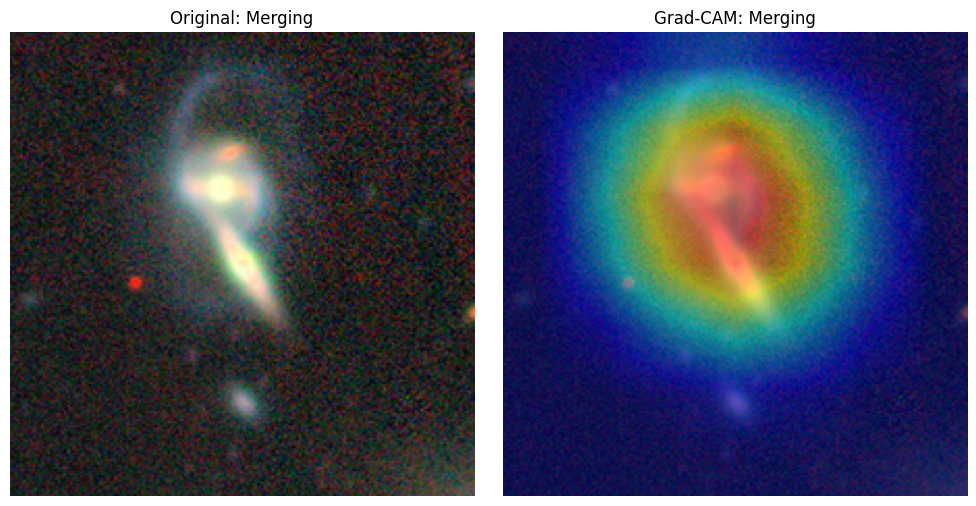

Saved your first heatmap: /content/drive/MyDrive/astralai/first_gradcam.png


In [13]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

model.eval()
idx = int(val_idx[0])                 # one held-out image
raw = images[idx]                     # uint8 256x256x3
true_label = int(labels[idx])

input_tensor = val_tf(Image.fromarray(raw)).unsqueeze(0).to(device)
pred = model(input_tensor).argmax(1).item()
print("True:", CLASS_NAMES[true_label], "| Predicted:", CLASS_NAMES[pred])

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])
grayscale_cam = cam(input_tensor=input_tensor,
                    targets=[ClassifierOutputTarget(pred)])[0]

rgb = np.array(Image.fromarray(raw).resize((224, 224))) / 255.0
overlay = show_cam_on_image(rgb.astype(np.float32), grayscale_cam, use_rgb=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(rgb);     ax[0].set_title(f"Original: {CLASS_NAMES[true_label]}"); ax[0].axis('off')
ax[1].imshow(overlay); ax[1].set_title(f"Grad-CAM: {CLASS_NAMES[pred]}");      ax[1].axis('off')
plt.tight_layout()
trophy = os.path.join(DATA_DIR, 'first_gradcam.png')
plt.savefig(trophy, dpi=120, bbox_inches='tight')
plt.show()
print("Saved your first heatmap:", trophy)

## Done — report back with two things

1. Your final **`val_acc`** number.
2. Whether the heatmap landed **on the galaxy** or on empty sky.

Those two facts tell me exactly what we build next. Commit this notebook to your `astralai` repo (that's the weekly ritual — progress you can *see*), and come find me.

**If something broke**, paste the error and the last cell that ran — we debug it together. That's expected and fine; hitting walls in week one is the whole point of doing the risky part first.